# Dataset Coverage: ToyMix vs DTI ESMC v2 vs LPM-24 OpenAI vs BBBC047

SMILES-level overlap between the four pre-training data sources currently in rotation:

| Source | Path | SMILES col |
|---|---|---|
| **ToyMix** = QM9 ∪ Tox21 ∪ ZINC12k | `data/graphium/neurips2023/small-dataset/` | `smiles` |
| **DTI ESMC v2** | `data/dti-processed/dti_esmc_100k_v2.csv` | `SMILES_nometa` |
| **LPM-24 OpenAI** | `data/dti-processed/litopenai_lpm24cap_small.csv` | `SMILES_nometa` |
| **BBBC047** | `/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv` | `SMILES` |

All SMILES are canonicalized via RDKit before set comparison. Canonical sets are cached to `../datacache/smiles_sets/` so reruns are fast.

In [1]:
import pickle
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import RDLogger
from tqdm.auto import tqdm

RDLogger.DisableLog('rdApp.*')

SMALL         = Path('/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/small-dataset')
DTI_V2_PATH   = Path('/home/shpark/prj-molrepr/graphium/data/dti-processed/dti_esmc_100k_v2.csv')
LPM24_OA_PATH = Path('/home/shpark/prj-molrepr/graphium/data/dti-processed/litopenai_lpm24cap_small.csv')
BBBC047_PATH  = Path('/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv')

CACHE_DIR = Path('../datacache/smiles_sets')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'QM9':          (SMALL / 'qm9.csv',                'smiles'),
    'Tox21':        (SMALL / 'Tox21-7k-12-labels.csv', 'smiles'),
    'ZINC12k':      (SMALL / 'ZINC12k.csv',            'smiles'),
    'DTI_ESMC_v2':  (DTI_V2_PATH,                      'SMILES_nometa'),
    'LPM24_OpenAI': (LPM24_OA_PATH,                    'SMILES_nometa'),
    'BBBC047':      (BBBC047_PATH,                     'SMILES'),
}

# 'MAIN' = the four sources we ultimately care about; 'ORDER' adds the ToyMix components
MAIN  = ['ToyMix', 'DTI_ESMC_v2', 'LPM24_OpenAI', 'BBBC047']
ORDER = ['ToyMix', 'QM9', 'Tox21', 'ZINC12k', 'DTI_ESMC_v2', 'LPM24_OpenAI', 'BBBC047']

## 1. Canonicalize and load each dataset's SMILES set

In [2]:
def canonicalize_set(smiles_iter):
    """Return a set of canonical SMILES, dropping invalid entries."""
    out = set()
    for s in smiles_iter:
        if not isinstance(s, str):
            continue
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue
        out.add(Chem.MolToSmiles(mol, canonical=True))
    return out

def load_canonical(name, path, col):
    cache = CACHE_DIR / f'{name}.pkl'
    if cache.exists():
        with open(cache, 'rb') as f:
            return pickle.load(f)
    df = pd.read_csv(path, usecols=[col])
    raw = df[col].dropna().tolist()
    canon = canonicalize_set(tqdm(raw, desc=f'{name} canon', leave=False))
    with open(cache, 'wb') as f:
        pickle.dump(canon, f)
    return canon

canon_sets = {name: load_canonical(name, path, col) for name, (path, col) in DATASETS.items()}
canon_sets['ToyMix'] = canon_sets['QM9'] | canon_sets['Tox21'] | canon_sets['ZINC12k']

pd.DataFrame(
    [{'dataset': n, 'unique_canon_smiles': len(canon_sets[n])} for n in ORDER]
).set_index('dataset')

,unique_canon_smiles
dataset,
ToyMix,153226
QM9,133798
Tox21,7831
ZINC12k,12000
DTI_ESMC_v2,97466
LPM24_OpenAI,159885
BBBC047,109645


## 2. Pairwise overlap (intersection counts)

In [3]:
inter = pd.DataFrame(index=ORDER, columns=ORDER, dtype=int)
for a in ORDER:
    for b in ORDER:
        inter.loc[a, b] = len(canon_sets[a] & canon_sets[b])
inter

,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,LPM24_OpenAI,BBBC047
ToyMix,153226.0,133798.0,7831.0,12000.0,503.0,1290.0,1230.0
QM9,133798.0,133798.0,402.0,0.0,32.0,297.0,98.0
Tox21,7831.0,402.0,7831.0,1.0,483.0,1140.0,1167.0
ZINC12k,12000.0,0.0,1.0,12000.0,4.0,0.0,20.0
DTI_ESMC_v2,503.0,32.0,483.0,4.0,97466.0,153.0,713.0
LPM24_OpenAI,1290.0,297.0,1140.0,0.0,153.0,159885.0,425.0
BBBC047,1230.0,98.0,1167.0,20.0,713.0,425.0,109645.0


## 3. Coverage matrix

**Asymmetric.** `coverage[row, col] = |row ∩ col| / |row|` — the fraction of `row`'s SMILES that are also present in `col`. Diagonal is 1.0.

In [4]:
coverage = pd.DataFrame(index=ORDER, columns=ORDER, dtype=float)
for a in ORDER:
    na = len(canon_sets[a])
    for b in ORDER:
        coverage.loc[a, b] = (len(canon_sets[a] & canon_sets[b]) / na) if na else np.nan
(coverage * 100).round(2).astype(str) + '%'

,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,LPM24_OpenAI,BBBC047
ToyMix,100.0%,87.32%,5.11%,7.83%,0.33%,0.84%,0.8%
QM9,100.0%,100.0%,0.3%,0.0%,0.02%,0.22%,0.07%
Tox21,100.0%,5.13%,100.0%,0.01%,6.17%,14.56%,14.9%
ZINC12k,100.0%,0.0%,0.01%,100.0%,0.03%,0.0%,0.17%
DTI_ESMC_v2,0.52%,0.03%,0.5%,0.0%,100.0%,0.16%,0.73%
LPM24_OpenAI,0.81%,0.19%,0.71%,0.0%,0.1%,100.0%,0.27%
BBBC047,1.12%,0.09%,1.06%,0.02%,0.65%,0.39%,100.0%


## 4. Jaccard similarity (symmetric)

`jaccard[a, b] = |a ∩ b| / |a ∪ b|`.

In [5]:
jaccard = pd.DataFrame(index=ORDER, columns=ORDER, dtype=float)
for a in ORDER:
    for b in ORDER:
        union = len(canon_sets[a] | canon_sets[b])
        jaccard.loc[a, b] = (len(canon_sets[a] & canon_sets[b]) / union) if union else np.nan
jaccard.round(4)

,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,LPM24_OpenAI,BBBC047
ToyMix,1.0000,0.8732,0.0511,0.0783,0.0020,0.0041,0.0047
QM9,0.8732,1.0000,0.0028,0.0000,0.0001,0.0010,0.0004
Tox21,0.0511,0.0028,1.0000,0.0001,0.0046,0.0068,0.0100
ZINC12k,0.0783,0.0000,0.0001,1.0000,0.0000,0.0000,0.0002
DTI_ESMC_v2,0.0020,0.0001,0.0046,0.0000,1.0000,0.0006,0.0035
LPM24_OpenAI,0.0041,0.0010,0.0068,0.0000,0.0006,1.0000,0.0016
BBBC047,0.0047,0.0004,0.0100,0.0002,0.0035,0.0016,1.0000


## 5. Heatmaps

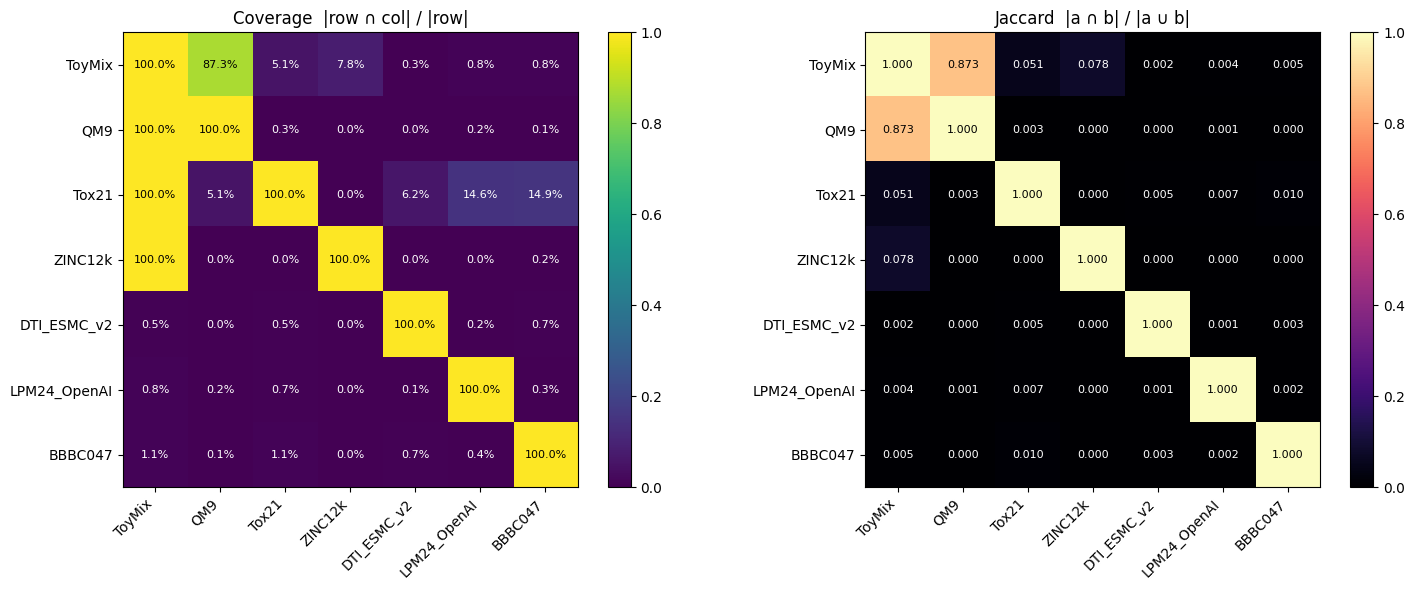

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im0 = axes[0].imshow(coverage.values.astype(float), cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Coverage  |row ∩ col| / |row|')
axes[0].set_xticks(range(len(ORDER))); axes[0].set_xticklabels(ORDER, rotation=45, ha='right')
axes[0].set_yticks(range(len(ORDER))); axes[0].set_yticklabels(ORDER)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v = coverage.values[i, j]
        axes[0].text(j, i, f'{v*100:.1f}%', ha='center', va='center',
                     color='white' if v < 0.5 else 'black', fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(jaccard.values.astype(float), cmap='magma', vmin=0, vmax=1)
axes[1].set_title('Jaccard  |a ∩ b| / |a ∪ b|')
axes[1].set_xticks(range(len(ORDER))); axes[1].set_xticklabels(ORDER, rotation=45, ha='right')
axes[1].set_yticks(range(len(ORDER))); axes[1].set_yticklabels(ORDER)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v = jaccard.values[i, j]
        axes[1].text(j, i, f'{v:.3f}', ha='center', va='center',
                     color='white' if v < 0.5 else 'black', fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 6. Multi-set overlap: ToyMix / DTI ESMC v2 / LPM-24 OpenAI / BBBC047

All pairwise, triple, and quadruple intersections on the four main sources, using **canonical SMILES** as the identity.

In [7]:
sets4 = {n: canon_sets[n] for n in MAIN}

print('Set sizes (canonical SMILES):')
for n in MAIN:
    print(f'  {n:13} : {len(sets4[n]):>7,}')
union_all = set().union(*sets4.values())
print(f'  {"UNION":13} : {len(union_all):>7,}')
print()

print('PAIRS  (a ∩ b):')
pair_rows = []
for a, b in combinations(MAIN, 2):
    ab = sets4[a] & sets4[b]
    un = sets4[a] | sets4[b]
    smaller = min(len(sets4[a]), len(sets4[b]))
    pair_rows.append({
        'A': a, 'B': b,
        '|A∩B|': len(ab),
        'jaccard': round(len(ab) / len(un), 4) if un else float('nan'),
        'pct_of_smaller': f'{100*len(ab)/smaller:.2f}%' if smaller else 'n/a',
    })
print(pd.DataFrame(pair_rows).to_string(index=False))
print()

print('TRIPLES  (a ∩ b ∩ c):')
trip_rows = []
for trio in combinations(MAIN, 3):
    inter_t = sets4[trio[0]] & sets4[trio[1]] & sets4[trio[2]]
    trip_rows.append({'sets': ' ∩ '.join(trio), 'count': len(inter_t)})
print(pd.DataFrame(trip_rows).to_string(index=False))
print()

quad = sets4[MAIN[0]] & sets4[MAIN[1]] & sets4[MAIN[2]] & sets4[MAIN[3]]
print(f'QUADRUPLE  {" ∩ ".join(MAIN)} : {len(quad):,}')

Set sizes (canonical SMILES):
  ToyMix        : 153,226
  DTI_ESMC_v2   :  97,466
  LPM24_OpenAI  : 159,885
  BBBC047       : 109,645
  UNION         : 516,323

PAIRS  (a ∩ b):
           A            B  |A∩B|  jaccard pct_of_smaller
      ToyMix  DTI_ESMC_v2    503   0.0020          0.52%
      ToyMix LPM24_OpenAI   1290   0.0041          0.84%
      ToyMix      BBBC047   1230   0.0047          1.12%
 DTI_ESMC_v2 LPM24_OpenAI    153   0.0006          0.16%
 DTI_ESMC_v2      BBBC047    713   0.0035          0.73%
LPM24_OpenAI      BBBC047    425   0.0016          0.39%

TRIPLES  (a ∩ b ∩ c):
                                sets  count
 ToyMix ∩ DTI_ESMC_v2 ∩ LPM24_OpenAI     52
      ToyMix ∩ DTI_ESMC_v2 ∩ BBBC047    182
     ToyMix ∩ LPM24_OpenAI ∩ BBBC047    175
DTI_ESMC_v2 ∩ LPM24_OpenAI ∩ BBBC047     32

QUADRUPLE  ToyMix ∩ DTI_ESMC_v2 ∩ LPM24_OpenAI ∩ BBBC047 : 26


## 7. Four-set region sizes

Every molecule in the union belongs to exactly one of the 15 non-empty regions of a 4-set Venn diagram. The bar chart below counts each region; the membership grid above each bar encodes which of the four sources contain it.

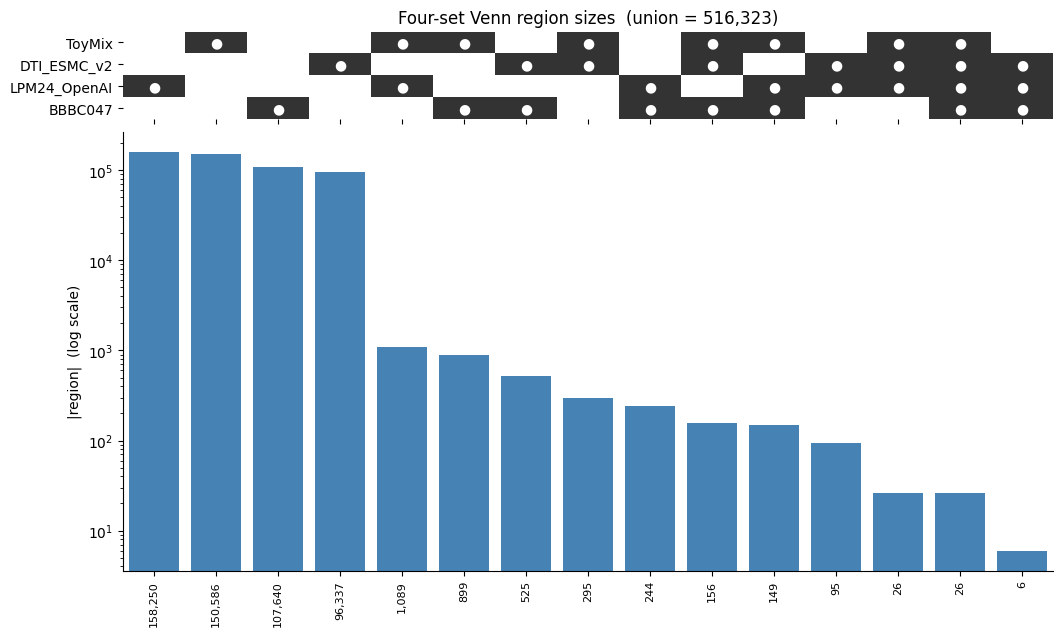

matplotlib_venn not installed — skipping 3-way Venn plot.


,region,count
0,LPM24_OpenAI,158250
1,ToyMix,150586
2,BBBC047,107640
3,DTI_ESMC_v2,96337
4,ToyMix + LPM24_OpenAI,1089
5,ToyMix + BBBC047,899
6,DTI_ESMC_v2 + BBBC047,525
7,ToyMix + DTI_ESMC_v2,295
8,LPM24_OpenAI + BBBC047,244
9,ToyMix + DTI_ESMC_v2 + BBBC047,156


In [8]:
# 15 non-empty regions of the 4-set Venn, plus a 3-set sub-Venn for the heavy-overlap sources
region_counts = {}
for r in range(1, len(MAIN) + 1):
    for combo in combinations(MAIN, r):
        inc = [sets4[n] for n in combo]
        exc = [sets4[n] for n in MAIN if n not in combo]
        region = set.intersection(*inc)
        for e in exc:
            region = region - e
        region_counts[combo] = len(region)

ordered = sorted(region_counts.items(), key=lambda kv: -kv[1])
values  = [v for _, v in ordered]

fig, (axg, axb) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 5], 'hspace': 0.05},
)

grid = np.array([[1 if n in combo else 0 for combo, _ in ordered] for n in MAIN])
axg.imshow(grid, cmap='Greys', aspect='auto', vmin=0, vmax=1.2)
axg.set_yticks(range(len(MAIN))); axg.set_yticklabels(MAIN)
axg.set_xticks([])
for spine in axg.spines.values():
    spine.set_visible(False)
for i in range(len(MAIN)):
    for j in range(len(ordered)):
        if grid[i, j]:
            axg.text(j, i, '●', ha='center', va='center', color='white', fontsize=10)
axg.set_title(f'Four-set Venn region sizes  (union = {len(union_all):,})')

x = np.arange(len(ordered))
axb.bar(x, values, color='steelblue')
axb.set_yscale('log')
axb.set_ylabel('|region|  (log scale)')
axb.set_xticks(x)
axb.set_xticklabels([f'{v:,}' for v in values], rotation=90, fontsize=8)
axb.set_xlim(-0.5, len(ordered) - 0.5)
for spine in ('top', 'right'):
    axb.spines[spine].set_visible(False)
plt.show()

# Optional 3-way Venn on the non-ToyMix sources (where overlap is most interesting)
try:
    from matplotlib_venn import venn3
    fig, ax = plt.subplots(figsize=(7, 6))
    venn3(
        [canon_sets['DTI_ESMC_v2'], canon_sets['LPM24_OpenAI'], canon_sets['BBBC047']],
        set_labels=('DTI ESMC v2', 'LPM-24 OpenAI', 'BBBC047'),
        ax=ax,
    )
    ax.set_title('Canonical-SMILES overlap (non-ToyMix sources)')
    plt.show()
except ImportError:
    print('matplotlib_venn not installed — skipping 3-way Venn plot.')

pd.DataFrame({
    'region': [' + '.join(c) for c, _ in ordered],
    'count':  values,
})